# Iris Species Classification

This notebook walks through a complete **supervised classification** workflow on the built-in Iris dataset. We will:

1. Load and explore the data
2. Split observations into training and test sets
3. Train several classification models with 10-fold cross-validation
4. Select the best-performing model
5. Evaluate the final model on held-out test data

All random operations use a fixed seed so results are reproducible.

## 1. Setup

Load the packages needed for modeling, resampling, and visualization. We set a global random seed before any stochastic step.

In [17]:
# Reproducibility: same seed for splitting and model training
RANDOM_SEED <- 42L
set.seed(RANDOM_SEED)

library(caret)      # unified interface for model training and evaluation
library(ggplot2)    # grammar-of-graphics plotting
library(dplyr)      # data manipulation
library(tidyr)      # tidy data reshaping
library(corrplot)   # correlation matrix visualization

theme_set(theme_minimal(base_size = 12))

## 2. Load the Iris Dataset

The Iris dataset ships with base R. Each row is one flower; the **target variable** is `Species` (three classes). The four numeric columns are measurements of sepal and petal dimensions in centimeters.

In [18]:
data(iris)

# Work with a clean copy; ensure the response is a factor
iris_df <- iris
iris_df$Species <- factor(iris_df$Species)

head(iris_df)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


## 3. Exploratory Data Analysis

Before modeling, we inspect data types, class balance, summary statistics, relationships among features, and how features separate the species.

In [19]:
# Structure and dimensions
str(iris_df)
cat("\nDimensions:", paste(dim(iris_df), collapse = " x "), "\n")

# Class distribution (balanced: 50 per species)
cat("\nClass counts:\n")
print(table(iris_df$Species))

# Descriptive statistics for all variables
summary(iris_df)

'data.frame':	150 obs. of  5 variables:
 $ Sepal.Length: num  5.1 4.9 4.7 4.6 5 5.4 4.6 5 4.4 4.9 ...
 $ Sepal.Width : num  3.5 3 3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 ...
 $ Petal.Length: num  1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 ...
 $ Petal.Width : num  0.2 0.2 0.2 0.2 0.2 0.4 0.3 0.2 0.2 0.1 ...
 $ Species     : Factor w/ 3 levels "setosa","versicolor",..: 1 1 1 1 1 1 1 1 1 1 ...

Dimensions: 150 x 5 

Class counts:

    setosa versicolor  virginica 
        50         50         50 


  Sepal.Length    Sepal.Width     Petal.Length    Petal.Width   
 Min.   :4.300   Min.   :2.000   Min.   :1.000   Min.   :0.100  
 1st Qu.:5.100   1st Qu.:2.800   1st Qu.:1.600   1st Qu.:0.300  
 Median :5.800   Median :3.000   Median :4.350   Median :1.300  
 Mean   :5.843   Mean   :3.057   Mean   :3.758   Mean   :1.199  
 3rd Qu.:6.400   3rd Qu.:3.300   3rd Qu.:5.100   3rd Qu.:1.800  
 Max.   :7.900   Max.   :4.400   Max.   :6.900   Max.   :2.500  
       Species  
 setosa    :50  
 versicolor:50  
 virginica :50  
                
                
                

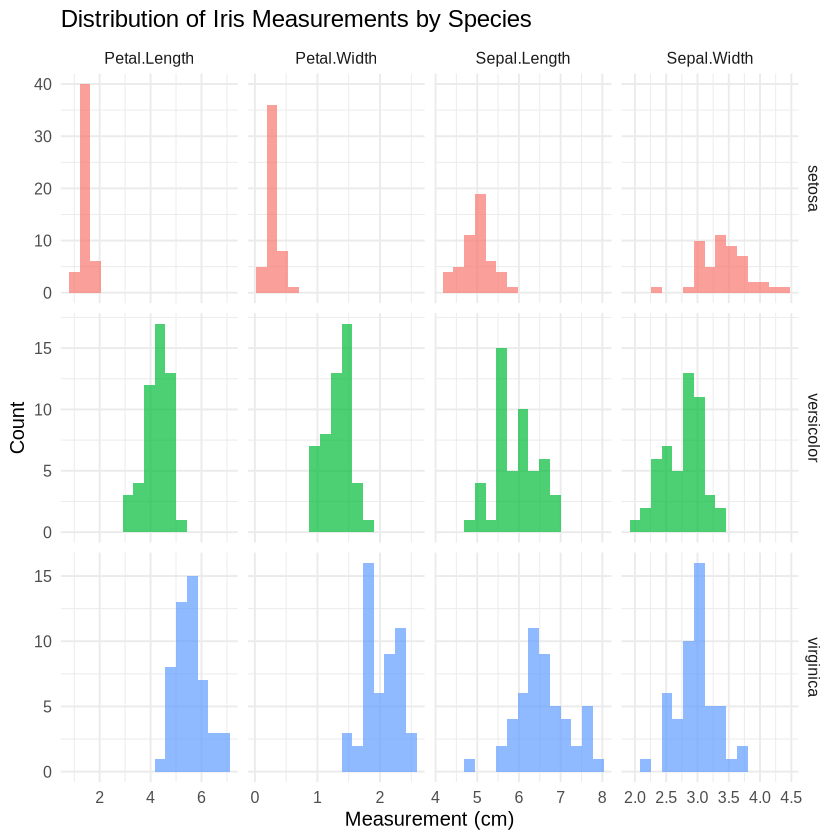

In [20]:
# Pairwise scatter plots colored by species
feature_cols <- c("Sepal.Length", "Sepal.Width", "Petal.Length", "Petal.Width")

iris_long <- iris_df |>
  pivot_longer(cols = all_of(feature_cols), names_to = "feature", values_to = "value")

ggplot(iris_long, aes(x = value, fill = Species)) +
  geom_histogram(bins = 15, alpha = 0.7, position = "identity") +
  facet_grid(Species ~ feature, scales = "free") +
  labs(
    title = "Distribution of Iris Measurements by Species",
    x = "Measurement (cm)",
    y = "Count"
  ) +
  theme(legend.position = "none")

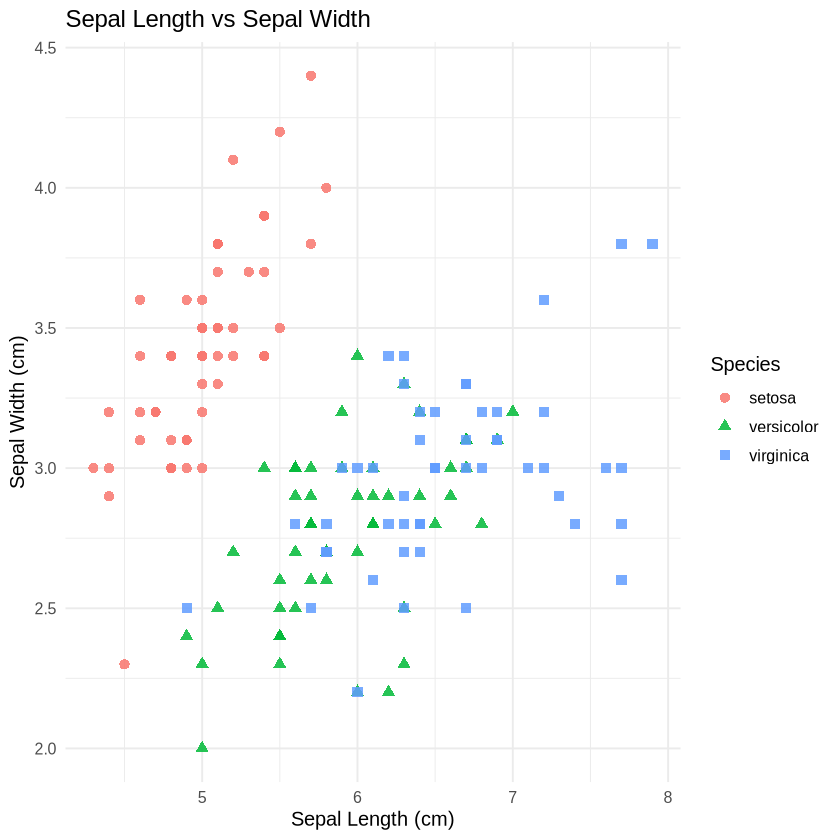

In [21]:
# Sepal dimensions: quick view of linear separability
ggplot(iris_df, aes(x = Sepal.Length, y = Sepal.Width, color = Species, shape = Species)) +
  geom_point(size = 2.5, alpha = 0.85) +
  labs(
    title = "Sepal Length vs Sepal Width",
    x = "Sepal Length (cm)",
    y = "Sepal Width (cm)"
  )

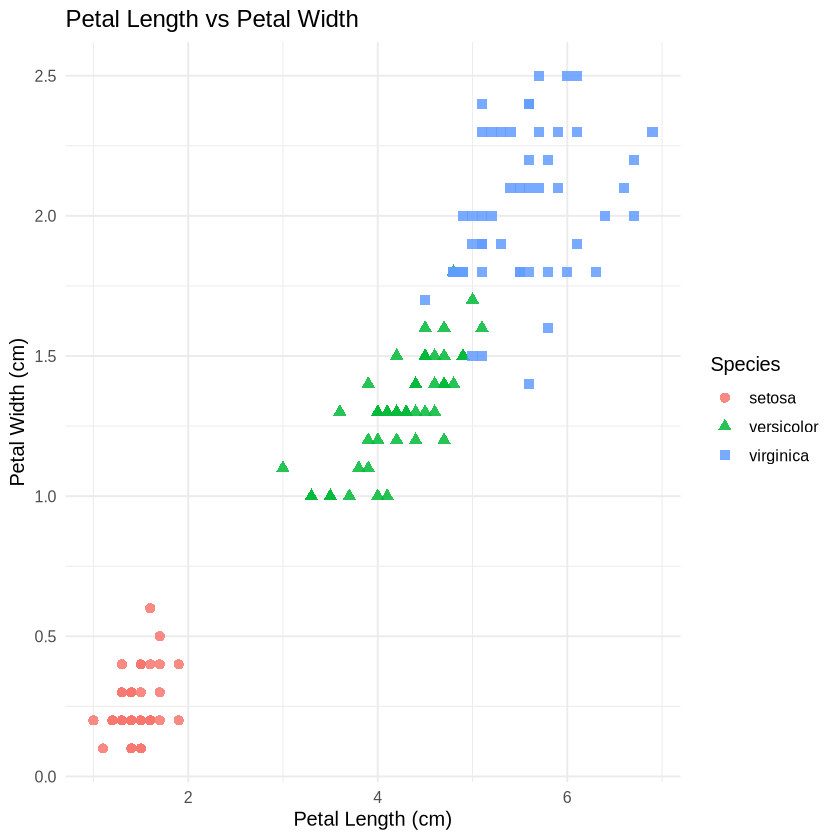

In [22]:
# Petal dimensions often provide stronger separation between species
ggplot(iris_df, aes(x = Petal.Length, y = Petal.Width, color = Species, shape = Species)) +
  geom_point(size = 2.5, alpha = 0.85) +
  labs(
    title = "Petal Length vs Petal Width",
    x = "Petal Length (cm)",
    y = "Petal Width (cm)"
  )

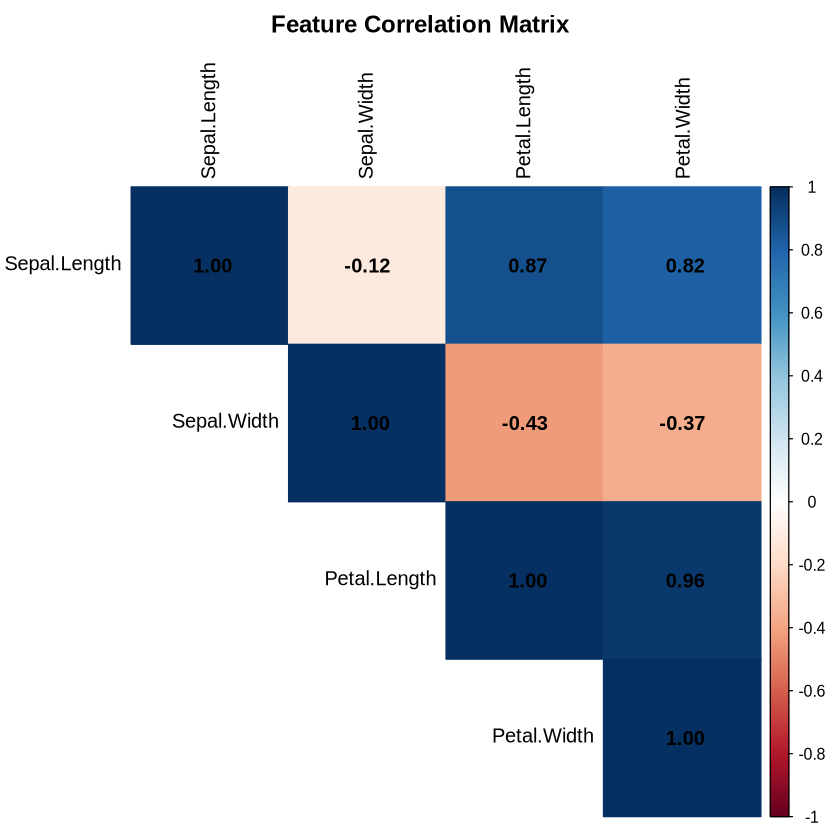

In [23]:
# Correlation among numeric predictors
feature_matrix <- iris_df[, feature_cols]
cor_matrix <- cor(feature_matrix)

corrplot(
  cor_matrix,
  method = "color",
  type = "upper",
  addCoef.col = "black",
  tl.col = "black",
  title = "Feature Correlation Matrix",
  mar = c(0, 0, 2, 0)
)

**Observations:** *Setosa* is typically well separated from the other two species, especially on petal measurements. *Versicolor* and *virginica* overlap somewhat, which makes them harder to classify. Petal length and width are strongly correlated.

## 4. Train / Test Split

We hold out **20%** of the data for final evaluation. `createDataPartition` performs a **stratified** split so each species appears in training and test sets in roughly the same proportions.

In [24]:
set.seed(RANDOM_SEED)

train_index <- createDataPartition(
  y = iris_df$Species,
  p = 0.80,
  list = FALSE
)

train_data <- iris_df[train_index, , drop = FALSE]
test_data  <- iris_df[-train_index, , drop = FALSE]

cat("Training rows:", nrow(train_data), "\n")
cat("Test rows:", nrow(test_data), "\n\n")
cat("Training class counts:\n")
print(table(train_data$Species))
cat("\nTest class counts:\n")
print(table(test_data$Species))

Training rows: 120 
Test rows: 30 

Training class counts:

    setosa versicolor  virginica 
        40         40         40 

Test class counts:

    setosa versicolor  virginica 
        10         10         10 


## 5. Model Training with 10-Fold Cross-Validation

We compare six classification algorithms through `caret::train`. All models share the same resampling scheme:

- **10-fold cross-validation** on the training set only
- **Accuracy** as the primary tuning/selection metric
- Class probabilities retained for optional probability-based summaries

| Method key | Algorithm |
|------------|-----------|
| `lda` | Linear Discriminant Analysis |
| `knn` | k-Nearest Neighbors |
| `rpart` | Decision Tree (CART) |
| `nb` | Naive Bayes |
| `svmRadial` | Support Vector Machine (RBF kernel) |
| `rf` | Random Forest |

In [25]:
cv_control <- trainControl(
  method = "cv",
  number = 10,
  classProbs = TRUE,
  savePredictions = "final",
  allowParallel = FALSE  # keeps notebook output deterministic
)

# Formula: predict Species from all four measurement features
model_formula <- Species ~ Sepal.Length + Sepal.Width + Petal.Length + Petal.Width

# Candidate algorithms and optional hyperparameter grids
model_catalog <- list(
  lda = list(method = "lda"),
  knn = list(
    method = "knn",
    tuneGrid = data.frame(k = c(3, 5, 7, 9, 11))
  ),
  rpart = list(method = "rpart"),
  nb = list(method = "nb"),
  svmRadial = list(
    method = "svmRadial",
    tuneLength = 5
  ),
  rf = list(
    method = "rf",
    tuneGrid = data.frame(mtry = c(2, 3, 4))
  )
)

In [26]:
# Train each model; reset seed so CV folds are identical across runs
trained_models <- list()

for (model_name in names(model_catalog)) {
  set.seed(RANDOM_SEED)
  spec <- model_catalog[[model_name]]

  cat("Training:", model_name, "...\n")

  train_args <- c(
    list(
      form = model_formula,
      data = train_data,
      trControl = cv_control,
      metric = "Accuracy"
    ),
    spec
  )

  trained_models[[model_name]] <- do.call(train, train_args)
}

cat("\nAll models trained.\n")

Training: lda ...
Training: knn ...
Training: rpart ...
Training: nb ...
Training: svmRadial ...
Training: rf ...

All models trained.


In [27]:
# Cross-validated performance summary for each model
cv_summary <- lapply(trained_models, function(model) {
  best <- model$results[which.max(model$results$Accuracy), , drop = FALSE]
  data.frame(
    Model = model$method,
    Best_Accuracy = round(best$Accuracy, 4),
    Kappa = round(best$Kappa, 4),
    stringsAsFactors = FALSE
  )
})

cv_results_table <- bind_rows(cv_summary, .id = "Model_ID") |>
  arrange(desc(Best_Accuracy))

print(cv_results_table)

   Model_ID     Model Best_Accuracy  Kappa
1       lda       lda        0.9917 0.9875
2       knn       knn        0.9750 0.9625
3        rf        rf        0.9750 0.9625
4        nb        nb        0.9667 0.9500
5 svmRadial svmRadial        0.9667 0.9500
6     rpart     rpart        0.9167 0.8750


## 6. Compare Models and Select the Best

We use `caret::resamples` to compare cross-validated accuracy distributions across models, then select the model with the highest CV accuracy.

In [28]:
model_comparison <- resamples(trained_models)
summary(model_comparison)


Call:
summary.resamples(object = model_comparison)

Models: lda, knn, rpart, nb, svmRadial, rf 
Number of resamples: 10 

Accuracy 
               Min.   1st Qu.    Median      Mean   3rd Qu. Max. NA's
lda       0.9166667 1.0000000 1.0000000 0.9916667 1.0000000    1    0
knn       0.9166667 0.9375000 1.0000000 0.9750000 1.0000000    1    0
rpart     0.8333333 0.8541667 0.9166667 0.9166667 0.9791667    1    0
nb        0.8333333 1.0000000 1.0000000 0.9666667 1.0000000    1    0
svmRadial 0.8333333 0.9375000 1.0000000 0.9666667 1.0000000    1    0
rf        0.8333333 1.0000000 1.0000000 0.9750000 1.0000000    1    0

Kappa 
           Min. 1st Qu. Median   Mean 3rd Qu. Max. NA's
lda       0.875 1.00000  1.000 0.9875 1.00000    1    0
knn       0.875 0.90625  1.000 0.9625 1.00000    1    0
rpart     0.750 0.78125  0.875 0.8750 0.96875    1    0
nb        0.750 1.00000  1.000 0.9500 1.00000    1    0
svmRadial 0.750 0.90625  1.000 0.9500 1.00000    1    0
rf        0.750 1.00000  1.000 0.

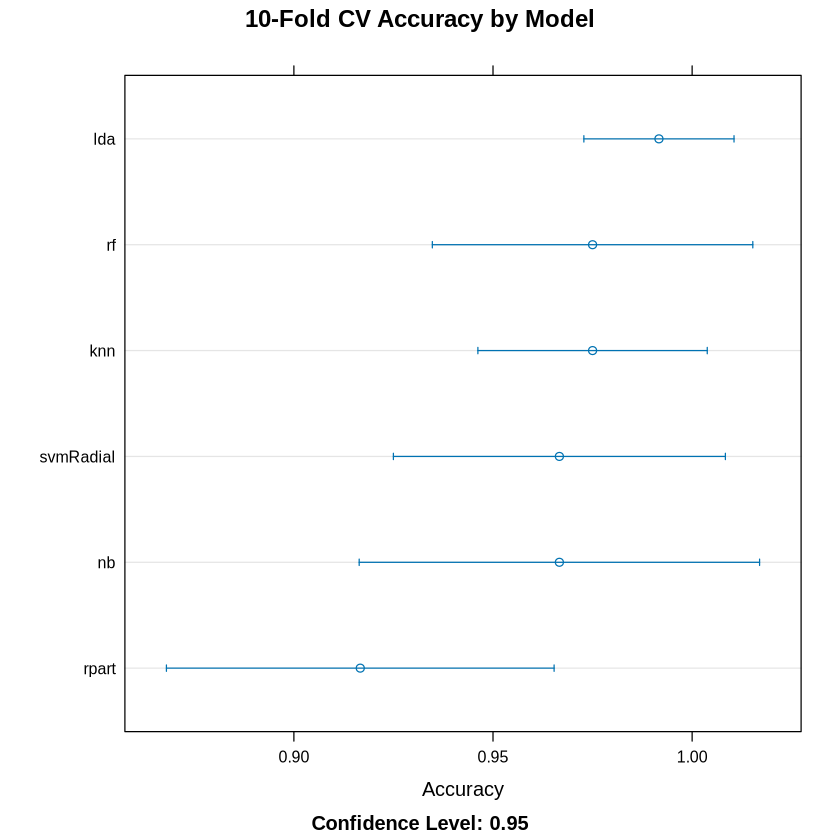

In [29]:
# Visual comparison of cross-validated accuracy
dotplot(model_comparison, metric = "Accuracy", main = "10-Fold CV Accuracy by Model")

In [30]:
best_model_id <- cv_results_table$Model_ID[1]
best_model <- trained_models[[best_model_id]]

cat("Selected model:", best_model_id, "\n")
print(best_model)

Selected model: lda 
Linear Discriminant Analysis 

120 samples
  4 predictor
  3 classes: 'setosa', 'versicolor', 'virginica' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 108, 108, 108, 108, 108, 108, ... 
Resampling results:

  Accuracy   Kappa 
  0.9916667  0.9875



## 7. Evaluate on the Held-Out Test Set

The test set was **not** used during training or cross-validation. We report overall accuracy, a confusion matrix, and per-class sensitivity (recall), specificity, precision, and F1 score.

In [31]:
test_predictions <- predict(best_model, newdata = test_data)
test_probabilities <- predict(best_model, newdata = test_data, type = "prob")

test_cm <- confusionMatrix(
  data = test_predictions,
  reference = test_data$Species,
  mode = "everything"  # valid options: sens_spec, prec_recall, everything
)

test_cm

Confusion Matrix and Statistics

            Reference
Prediction   setosa versicolor virginica
  setosa         10          0         0
  versicolor      0          9         1
  virginica       0          1         9

Overall Statistics
                                          
               Accuracy : 0.9333          
                 95% CI : (0.7793, 0.9918)
    No Information Rate : 0.3333          
    P-Value [Acc > NIR] : 8.747e-12       
                                          
                  Kappa : 0.9             
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: setosa Class: versicolor Class: virginica
Sensitivity                 1.0000            0.9000           0.9000
Specificity                 1.0000            0.9500           0.9500
Pos Pred Value              1.0000            0.9000           0.9000
Neg Pred Value              1.0000            0.9500           0.9500
P

In [32]:
# Extract key overall metrics
overall <- test_cm$overall

cat("Test-set accuracy:", round(overall["Accuracy"], 4), "\n")
cat("95% CI:", round(overall["AccuracyLower"], 4), "-",
    round(overall["AccuracyUpper"], 4), "\n")
cat("Kappa:", round(overall["Kappa"], 4), "\n\n")

cat("Per-class metrics (Sensitivity = Recall):\n")
print(round(test_cm$byClass[, c("Sensitivity", "Specificity", "Precision", "F1")], 4))

Test-set accuracy: 0.9333 
95% CI: 0.7793 - 0.9918 
Kappa: 0.9 

Per-class metrics (Sensitivity = Recall):
                  Sensitivity Specificity Precision  F1
Class: setosa             1.0        1.00       1.0 1.0
Class: versicolor         0.9        0.95       0.9 0.9
Class: virginica          0.9        0.95       0.9 0.9


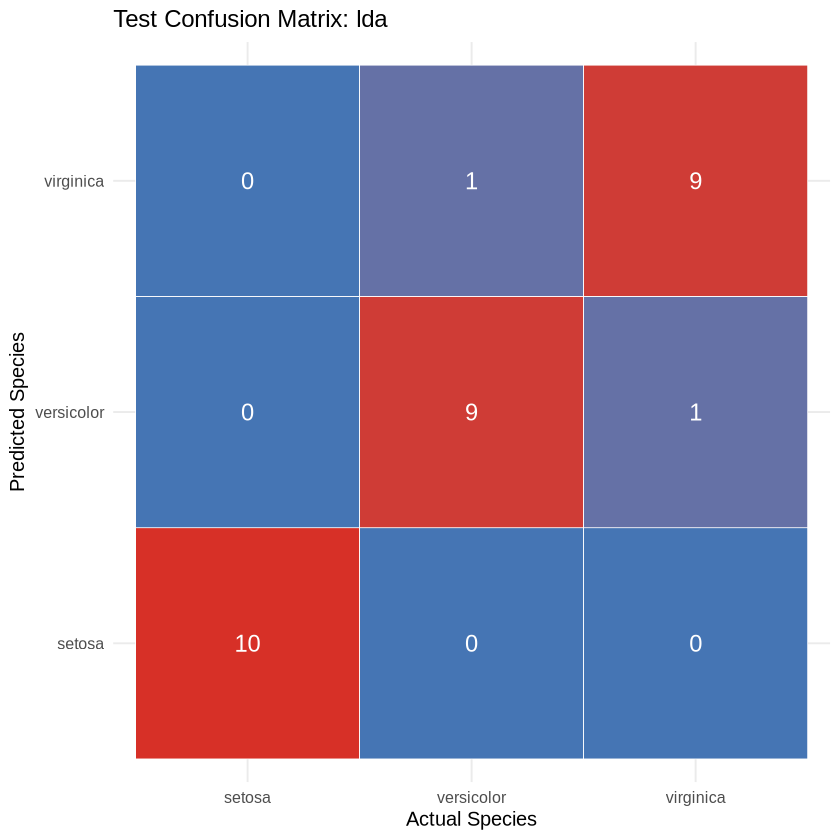

In [33]:
# Visual confusion matrix
cm_table <- as.data.frame(test_cm$table)
colnames(cm_table) <- c("Predicted", "Reference", "Freq")

ggplot(cm_table, aes(x = Reference, y = Predicted, fill = Freq)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Freq), color = "white", size = 5) +
  scale_fill_gradient(low = "#4575b4", high = "#d73027") +
  labs(
    title = paste("Test Confusion Matrix:", best_model_id),
    x = "Actual Species",
    y = "Predicted Species"
  ) +
  theme(legend.position = "none")

## 8. Summary

This notebook demonstrated a standard classification pipeline:

1. **Explored** the Iris dataset with summaries and visualizations
2. **Partitioned** data into training (80%) and test (20%) sets with stratification
3. **Trained** six classifiers under identical 10-fold cross-validation settings
4. **Selected** the model with the highest cross-validated accuracy
5. **Evaluated** generalization on unseen test data using accuracy, a confusion matrix, and per-class metrics

Because the Iris dataset is relatively small and well separated (especially for *setosa*), most reasonable models achieve high accuracy. Differences in cross-validation scores help illustrate how algorithm choice and hyperparameters affect performance even on simple data.